In [66]:
import os

# prototipo di schema naming per il dataset + verifica

data_path = "dummy"

folders = os.listdir(data_path)
files_dict = {}

for fol in folders:
    sub_path = os.path.join(data_path, fol)
    files_dict[fol] = os.listdir(sub_path)

# display(files_dict)

n_classi = len(folders)
n_file = len(files_dict[fol])
n_eventi = 200

print(f"i see {n_classi} class folders each containing {n_file} files")

i = 0
j = 0
k = 0

train = 0
vali = 0
test = 0

tot = n_classi * n_file * n_eventi
printable = [0, 100]

for fol, files in files_dict.items():
    print(f"in folder {fol}")

    for j, file in enumerate(files):
        print(f"in file {file}")

        if j < 3:
            print("this goes to train")
            train_set = True
        else:
            print("this goes to vali / test")
            train_set = False

        for k in range(n_eventi):

            if train_set:
                if k in printable:
                    print(f"saved event #{k:4} from file {file} in class {fol} in dataset/train/{train:4}.png")
                train += 1
            else:
                if k < 100:
                    if k in printable:
                        print(f"saved event #{k:4} from file {file} in class {fol} in dataset/vali/ {vali:4}.png")
                    vali += 1
                else:
                    if k in printable:
                        print(f"saved event #{k:4} from file {file} in class {fol} in dataset/test/ {test:4}.png")
                    test += 1

print()
print(f"N eventi: {tot}")
print(f"dataset split: {train} / {vali} / {test}")
print(f"o, in proporzione: {train/tot} / {vali/tot} / {test/tot}")

# dummy test
n_classi = 8
n_file = 4
n_eventi = 200

train = 0
vali = 0
test = 0

tot = n_classi * n_file * n_eventi
printable = [0, 100]

for i in range(n_classi):

    for j in range(n_file):

        if j < 3:
            train_set = True
        else:
            train_set = False

        for k in range(n_eventi):

            if train_set:
                if k in printable:
                    print(f"saved event #{k:4} from file {j} in class {i} in dataset/train/{train:4}.png")
                train += 1
            else:
                if k < 100:
                    if k in printable:
                        print(f"saved event #{k:4} from file {j} in class {i} in dataset/vali/ {vali:4}.png")
                    vali += 1
                else:
                    if k in printable:
                        print(f"saved event #{k:4} from file {j} in class {i} in dataset/test/ {test:4}.png")
                    test += 1

print()
print(f"N eventi: {tot}")
print(f"dataset split: {train} / {vali} / {test}")
print(f"o, in proporzione: {train/tot} / {vali/tot} / {test/tot}")



i see 8 class folders each containing 4 files
in folder classe_1
in file dummy_1
this goes to train
saved event #   0 from file dummy_1 in class classe_1 in dataset/train/   0.png
saved event # 100 from file dummy_1 in class classe_1 in dataset/train/ 100.png
in file dummy_2
this goes to train
saved event #   0 from file dummy_2 in class classe_1 in dataset/train/ 200.png
saved event # 100 from file dummy_2 in class classe_1 in dataset/train/ 300.png
in file dummy_3
this goes to train
saved event #   0 from file dummy_3 in class classe_1 in dataset/train/ 400.png
saved event # 100 from file dummy_3 in class classe_1 in dataset/train/ 500.png
in file dummy_4
this goes to vali / test
saved event #   0 from file dummy_4 in class classe_1 in dataset/vali/    0.png
saved event # 100 from file dummy_4 in class classe_1 in dataset/test/    0.png
in folder classe_2
in file dummy_1
this goes to train
saved event #   0 from file dummy_1 in class classe_2 in dataset/train/ 600.png
saved event # 1

tensor([[ 204,  198,  199,  199,  201,  200,  198,  205,  201,  198,  202,  199,
          206,  198],
        [ 200,  199,  205,  199,  200,  203,  197,  199,  200,  200,  198,  201,
          197,  196],
        [ 201,  197,  201,  198, 3174,  202,  198,  204,  201,  201,  199,  196,
          202,  207],
        [ 200,  199,  199,  201,  199,  201,  201,  201,  197,  199,  200,  214,
          201,  198],
        [ 200,  200,  200,  198,  200,  201,  200,  196,  199,  198,  201,  200,
          198,  199],
        [ 202,  201,  198,  199,  195,  198,  203,  199,  197,  199,  200,  205,
          205,  198],
        [ 199,  199,  196,  199,  197,  199,  203,  203,  199,  202,  200,  199,
          198,  199],
        [ 199,  198,  200,  206,  198,  196,  202,  198,  201,  201,  198,  199,
          206,  198],
        [ 197,  200,  199,  199,  201,  198,  201,  200,  200,  200,  200,  202,
          206,  200],
        [ 198,  198,  200,  199,  200,  198,  204,  196,  201,  201,  197

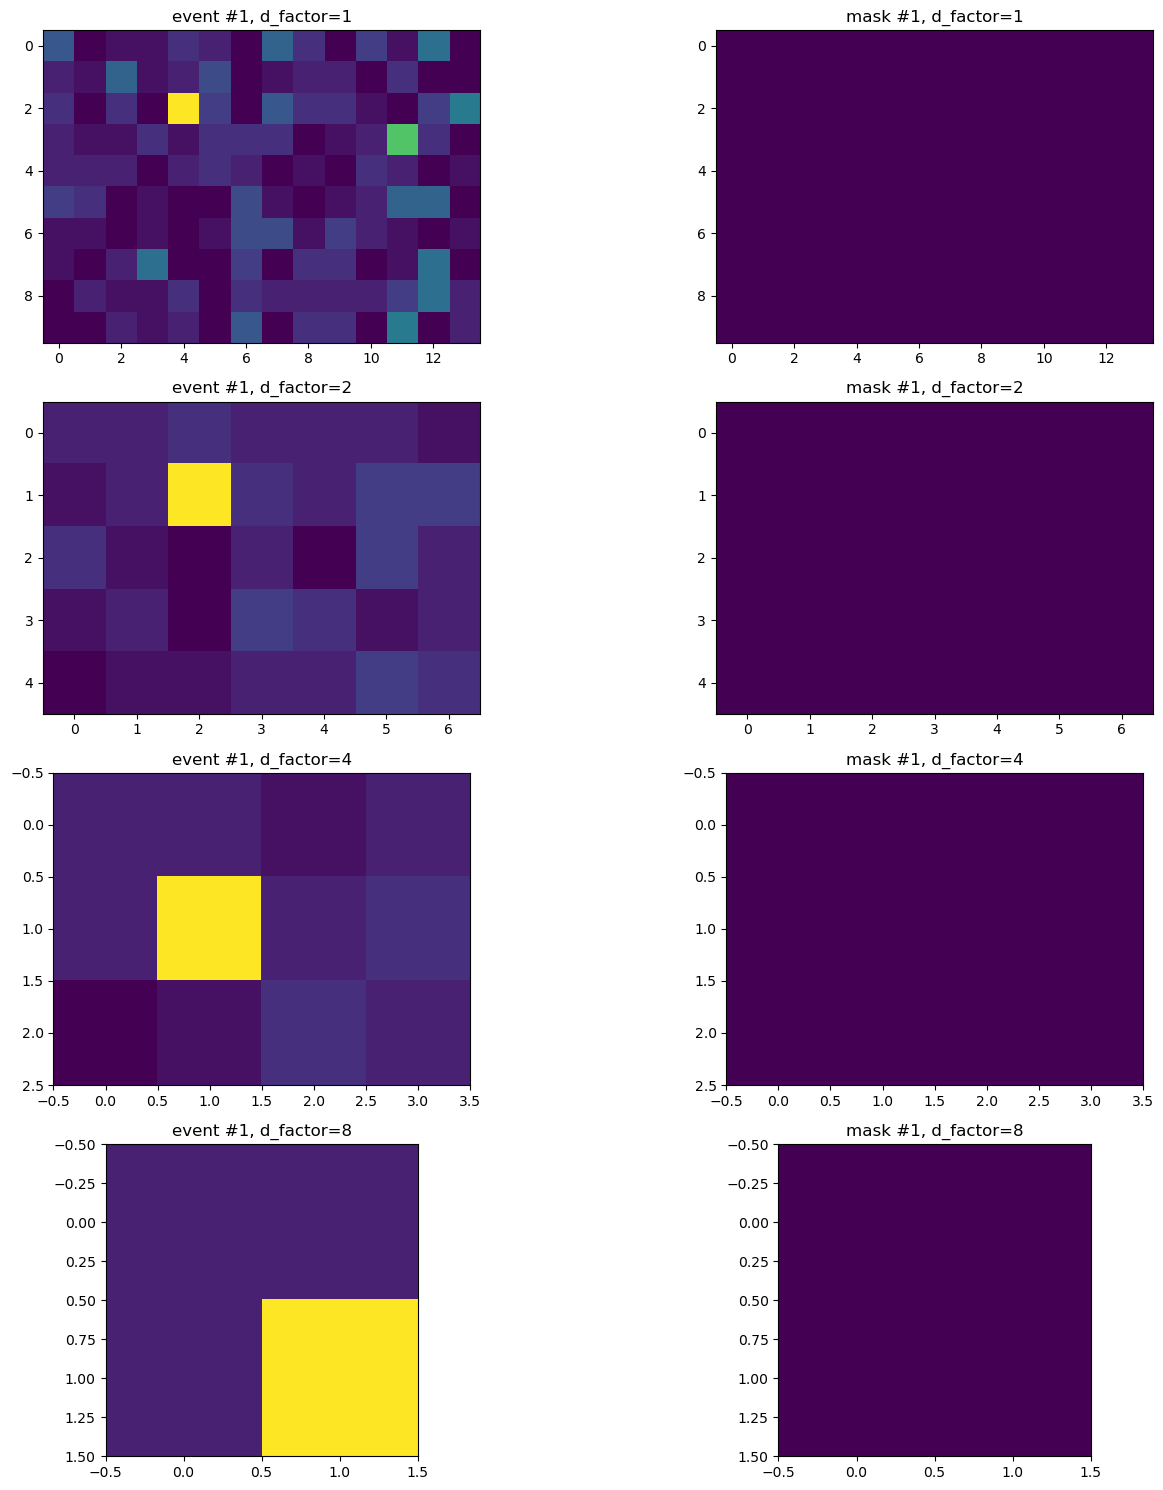

In [52]:
import cygnet
import imageio.v3 as iio
import torch
import numpy as np
from matplotlib import pyplot as plt

downscaling = 1

raw_data_path = "data/"
comp_data = cygnet.RootDataset(raw_data_path, downscaling)
raw_data = cygnet.RootDataset(raw_data_path, downscaling, True)

last = 0
size = (15,15)

listone = [1]

x_start = 0
x_end = 5000
y_start = 0
y_end = 3000

x_start = 2422
x_end = 2436
y_start = 630
y_end = 640

x_start_d = x_start // downscaling
x_end_d = x_end // downscaling
y_start_d = y_start // downscaling
y_end_d = y_end // downscaling

factors = [1, 2, 4, 8]

for i in listone:
    fig, axs = plt.subplots(len(factors), 2, figsize=size)
    n = 0
    for f in factors:
        data = cygnet.RootDataset(raw_data_path, f)
        ev, gt = data[i]
        x_start_d = x_start // f
        x_end_d = x_end // f
        y_start_d = y_start // f
        y_end_d = y_end // f
        axs[n,0].imshow(ev.squeeze()[y_start_d:y_end_d, x_start_d:x_end_d], vmin=cygnet.picmin, vmax=cygnet.picmax)
        axs[n,0].set_title(f"event #{i}, d_factor={f}")
        axs[n,1].imshow(gt.squeeze()[y_start_d:y_end_d, x_start_d:x_end_d])
        axs[n,1].set_title(f"mask #{i}, d_factor={f}")
        print(ev.squeeze()[y_start_d:y_end_d, x_start_d:x_end_d])
        n += 1
    fig.tight_layout()


# for i in listone:
#     ev, gt = raw_data[i]
#     ev_d, gt_d = comp_data[i]
#     print(ev.shape)
#     fig, axs = plt.subplots(2, 2, figsize=size)
#     axs[0,0].imshow(ev.squeeze()[y_start:y_end, x_start:x_end], vmin=cygnet.picmin, vmax=cygnet.picmax)
#     axs[0,0].set_title("raw event")
#     axs[1,0].imshow(ev_d.squeeze()[y_start_d:y_end_d, x_start_d:x_end_d], vmin=cygnet.picmin, vmax=cygnet.picmax)
#     axs[1,0].set_title("downscaled event")
#     axs[0,1].imshow(gt.squeeze()[y_start:y_end, x_start:x_end])
#     axs[0,1].set_title("raw truth")
#     axs[1,1].imshow(gt_d.squeeze()[y_start_d:y_end_d, x_start_d:x_end_d])
#     axs[1,1].set_title("downscaled truth")
